# Olist E-Commerce: Tree-based Classification Models

**Project**: Customer Satisfaction Prediction
**Dataset**: Olist Brazilian E-Commerce (preprocessed)
**Objective**: Build and compare Decision Tree, Random Forest, and XGBoost models
             to predict customer satisfaction based on order characteristics

Model Pipeline:
1. Load preprocessed data from Olist_clean_data.csv
2. Feature engineering and target variable creation
3. Train-test split with temporal validation
4. Model training with class imbalance handling
5. Performance evaluation and comparison
6. Feature importance analysis

In [2]:
# =============================================================================
# LIBRARY IMPORTS
# =============================================================================

# Data manipulation
import numpy as np
import pandas as pd

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    roc_auc_score, 
    roc_curve,
    f1_score
)


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## Data Loading and Exploration

Loading the preprocessed Olist dataset from the preprocessing pipeline.
This dataset contains merged information from orders, products, customers, and reviews.

**Key columns for modeling:**
- Target: `review_score` (will be converted to binary)
- Features: All other columns except IDs and dates

In [4]:
# =============================================================================
# DATA LOADING
# =============================================================================

# Load preprocessed data
data = pd.read_csv("Olist_clean_data.csv")

print(f"✅ Data loaded: {data.shape[0]:,} rows, {data.shape[1]} columns")
print(f"Date range: {data['order_purchase_timestamp'].min()} to {data['order_purchase_timestamp'].max()}")

# Quick overview
data.head(3)

✅ Data loaded: 97,916 rows, 24 columns
Date range: 2016-09-04 to 2018-09-03


,order_id,review_score,review_date,order_purchase_timestamp,delivered_status,waiting_time,customer_unique_id,customer_state,number_payments,payment_value_sum,payment_type,number_items,total_price,total_freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_id,product_description_lenght,product_photos_qty,product_id,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,5,2017-09-22,2017-09-13,1,7,871766c5855e863f6eccc05f988b23cb,Southeast,1.0,72.19,credit_card,1.0,58.9,13.29,650.0,28.0,9.0,14.0,Miscellaneous and Other Items,48436dade18ac8b2bce089ec2a041202,598.0,4.0,4244733e06e7ecb4970a6e2683c13e61,Southeast
1,00018f77f2f0320c557190d7a144bdd3,4,2017-05-15,2017-04-26,1,16,eb28e67c4c0b83846050ddfb8a35d051,Southeast,1.0,259.83,credit_card,1.0,239.9,19.93,30000.0,50.0,30.0,40.0,Miscellaneous and Other Items,dd7ddc04e1b6c2c614352b383efe2d36,239.0,2.0,e5f2d52b802189ee658865ca93d83a8f,Southeast
2,000229ec398224ef6ca0657da4fc703e,5,2018-01-23,2018-01-14,1,8,3818d81c6709e39d06b2738a8d3a2474,Southeast,1.0,216.87,credit_card,1.0,199.0,17.87,3050.0,33.0,13.0,33.0,Home and Decoration,5b51032eddd242adc84c38acab88f23d,695.0,2.0,c777355d18b72b67abbeef9df44fd0fd,Southeast


In [5]:
# =============================================================================
# INITIAL DATA EXPLORATION
# =============================================================================

def explore_dataset(data, name="Dataset"):
    """Display comprehensive dataset statistics"""
    print(f"\n{'='*60}")
    print(f"DATASET OVERVIEW: {name}")
    print(f"{'='*60}")
    
    print(f"\n📊 Shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
    print(f"🔍 Memory usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"⚠️  Duplicates: {data.duplicated().sum()}")
    
    print(f"\n{'─'*60}")
    print("COLUMN SUMMARY:")
    print(f"{'─'*60}")
    
    summary = pd.DataFrame({
        'Type': data.dtypes,
        'Non-Null': data.count(),
        'Null Count': data.isnull().sum(),
        'Null %': (data.isnull().sum() / len(data) * 100).round(2),
        'Unique': data.nunique()
    })
    
    print(summary)

explore_dataset(data, "Olist Preprocessed")


DATASET OVERVIEW: Olist Preprocessed

📊 Shape: 97,916 rows × 24 columns
🔍 Memory usage: 82.19 MB
⚠️  Duplicates: 0

────────────────────────────────────────────────────────────
COLUMN SUMMARY:
────────────────────────────────────────────────────────────
                                  Type  Non-Null  Null Count  Null %  Unique
order_id                        object     97916           0     0.0   97916
review_score                     int64     97916           0     0.0       5
review_date                     object     97916           0     0.0     711
order_purchase_timestamp        object     97916           0     0.0     615
delivered_status                 int64     97916           0     0.0       2
waiting_time                     int64     97916           0     0.0     142
customer_unique_id              object     97916           0     0.0   94720
customer_state                  object     97916           0     0.0       5
number_payments                float64     97916    

### Date Type Conversions

**Objective:** Convert date strings to datetime objects for potential temporal analysis

**Columns to transform:**
- `review_date` - Customer review submission date
- `order_purchase_timestamp` - Original purchase date

**Rationale:** While not used as features in tree models, proper date types enable time-based filtering and analysis if needed.

In [7]:
# =============================================================================
# DATE TYPE CONVERSIONS
# =============================================================================

# Convert string dates to datetime and normalize to midnight
data["review_date"] = pd.to_datetime(data["review_date"]).dt.normalize()
data["order_purchase_timestamp"] = pd.to_datetime(data["order_purchase_timestamp"]).dt.normalize()

print("✅ Date columns converted to datetime format")
print(f"   review_date: {type(data.loc[0, 'review_date'])}")
print(f"   order_purchase_timestamp: {type(data.loc[0, 'order_purchase_timestamp'])}")

✅ Date columns converted to datetime format
   review_date: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
   order_purchase_timestamp: <class 'pandas._libs.tslibs.timestamps.Timestamp'>


### Dropping order_id

Order_id column is dropped as it doesn't add value to the model and is not suitable for any useful transformation.

In [9]:
data = data.drop(columns = 'order_id')

print('"✅ order_id column was dropped')

"✅ order_id column was dropped


## Target Variable Creation & Feature Engineering

This section focuses on creating the target variable and preparing features for modeling.

- ✅ Created `seller_topN` and `product_topN` (Pareto analysis)
- ✅ Created `repeat_customer` flag
- ✅ Reduced categories for states, payment types, etc.
- ✅ Created `review_delay` temporal feature
- ✅ Dropped polarized variables (delivered_status, number_payments, etc.)


**Target Variable Definition:**
- `good_review`: Binary classification (1 = satisfied customer, 0 = unsatisfied)
- Threshold: review_score = 5 → good_review = 1

### Target Variable Creation

**Decision:** Convert `review_score` (1-5 scale) into binary classification problem

**Rationale:** 
- Simplifies problem to "completely satisfied vs not completely satisfied" customers
- Scores 5 = Completely Satisfied (1)
- Scores 1-4 = Not completely satisfied (0)
- Creates balanced business objective: identify unhappy customers for intervention

✅ Binary target variable created

Class distribution:
good_review
1    56940
0    40976
Name: count, dtype: int64

Class balance: 58.15% satisfied


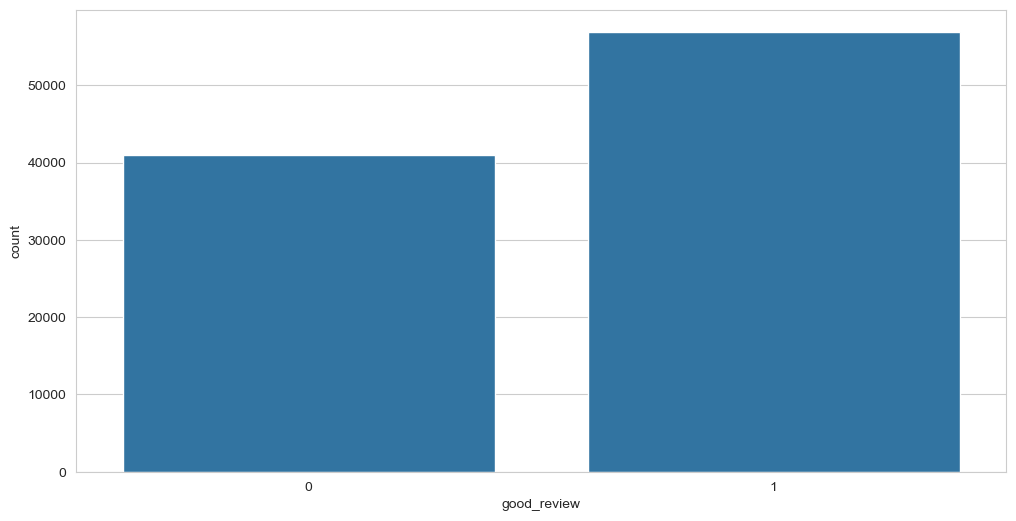

In [12]:
# =============================================================================
# TARGET VARIABLE CREATION
# =============================================================================

# Create binary satisfaction target
data['good_review'] = (data['review_score'] == 5).astype(int)

# Showing distribution
print("✅ Binary target variable created")
print(f"\nClass distribution:")
print(data['good_review'].value_counts())
print(f"\nClass balance: {data['good_review'].mean():.2%} satisfied")

sns.countplot(
    data = data,
    x = "good_review"
)

# Dropping original review_score column
data = data.drop(columns = 'review_score')

### Pareto analysis: seller_id & product_id

1. Creation of `seller_topN` and `product_topN` variables: which flag 20% top sellers and 30% top products that cover the 80% of total sales.

2. Drop of `seller_id` and `productr_id` columns: no longer necessary

In [14]:
# =============================================================================
# CREATING TOP SELLER FLAG
# =============================================================================

# Grouping data by seller_id and sorting by sales
sales_by_seller = (
    data.groupby('seller_id')['total_price']
    .sum()
    .sort_values(ascending=False)
)

# Caclulatng cumulative percentage of sales
pct_cum_sales = sales_by_seller.cumsum() / sales_by_seller.sum()

# Extracting how many sellers cover 80% of sales
num_sellers_80 = (pct_cum_sales <= 0.80).sum()
pct_sellers_80 = num_sellers_80/data['seller_id'].nunique()*100
print(f'{pct_sellers_80:.2f}% of sellers cover 80% of sales')

# Creating the top seller flag and adding it to the database
topN_sellers = sales_by_seller.head(num_sellers_80).index
data['seller_topN'] = data['seller_id'].isin(topN_sellers).astype(int)

# Dropping seller_id 
data = data.drop(columns = 'seller_id')

17.59% of sellers cover 80% of sales


In [15]:
# =============================================================================
# CREATING TOP PRODUCT FLAG
# =============================================================================

# Grouping data by product_id and sorting by sales
sales_by_product = (
    data.groupby('product_id')['total_price']
    .sum()
    .sort_values(ascending=False)
)

# Caclulatng cumulative percentage of sales
pct_cum_sales = sales_by_product.cumsum() / sales_by_product.sum()

# Extracting how many sellers cover 80% of sales
num_products_80 = (pct_cum_sales <= 0.80).sum()
pct_products_80 = num_products_80/data['product_id'].nunique()*100
print(f'{pct_products_80:.2f}% of products cover 80% of sales')

# Creating the top seller flag and adding it to the database
topN_products = sales_by_product.head(num_products_80).index
data['product_topN'] = data['product_id'].isin(topN_products).astype(int)

# Dropping product_id 
data = data.drop(columns = 'product_id')

26.38% of products cover 80% of sales


### Repeat_customer flag

1. Creation of the `repeat_customer` binary variable, which flags orders by customers that had previously used the platform;

2. Drop of `customer_unique_id` variable, as it is no longer needed.

In [17]:
# =============================================================================
# CREATING REPEAT CUSTOMER FLAG
# =============================================================================

# Calculating how many duplicate customers we have
num_dup_customers = data.duplicated(subset = "customer_unique_id", keep = "first").astype(int).sum()
pct_dup_customers = num_dup_customers / data["customer_unique_id"].nunique()*100
print(f'{pct_dup_customers:.2f}% of customers had previously bought through the platform.')

# Creating a binary variable 0/1 for duplicate customers
data = data.assign(
    repeat_customer = data.duplicated(subset = "customer_unique_id", keep = "first").astype(int)
)

# Dropping customer_unique_id
data = data.drop(columns = "customer_unique_id")

3.37% of customers had previously bought through the platform.


### Categorical variables: polarization testing & grouping

Categorical variable are selected as all qualitative variables and quantitive variables with few unique entries:
- `delivered_status` → num, 2 unique values;
- `customer_state` → str, 5 unique values;
- `number_payments` → num, 20 unique values;
- `payment_type` → str, 4 unique values;
- `number_items` → nume, 17 unique values;
- `product_category_name_english` → str, 7 unique values;
- `product_photos_qty` → num, 20 unique values;
- `seller_state` → str, 5 unique values.

In [19]:
# =============================================================================
# IDENTIFYING CATEGORICAL VARIABLES
# =============================================================================

for col in data:
    if data[col].nunique() < 50:
        print(f'{col}: {type(data.loc[0,col])}, {data[col].nunique()} unique values.')

delivered_status: <class 'numpy.int64'>, 2 unique values.
customer_state: <class 'str'>, 5 unique values.
number_payments: <class 'numpy.float64'>, 20 unique values.
payment_type: <class 'str'>, 4 unique values.
number_items: <class 'numpy.float64'>, 17 unique values.
product_category_name_english: <class 'str'>, 7 unique values.
product_photos_qty: <class 'numpy.float64'>, 20 unique values.
seller_state: <class 'str'>, 5 unique values.
good_review: <class 'numpy.int64'>, 2 unique values.
seller_topN: <class 'numpy.int64'>, 2 unique values.
product_topN: <class 'numpy.int64'>, 2 unique values.
repeat_customer: <class 'numpy.int64'>, 2 unique values.


In [20]:
# =============================================================================
# DEFININING CATEGORICAL VARIABLES EXPLORATION FUNCTION
# =============================================================================

def variable_exploration(db, column_name):
    
    # calculating count of values and cumulative perentage for each class 
    counts = db[column_name].value_counts()
    pct = counts/db[column_name].size * 100
    cumulative_pct = (counts/db[column_name].size).cumsum()*100
    
    # showing results in a table
    summary = pd.DataFrame({
        'Count' : counts,
        'Percentage of Total' : pct,
        'Cumulative percentage' : cumulative_pct
    })
    
    # showing results visually in a chart
    sns.countplot(data = db, x = column_name, hue = 'good_review')
    plt.xticks(rotation=45, ha='right')
    plt.show
    
    return summary

print("✅ Function defined successfully")

✅ Function defined successfully


#### Delivered_status

**Analysis findings**:
- 97.9% of orders were flagged as delivered

**Transformation decision**:
- **DROPPED** - Insufficient variance for prediction: polarized features add no discriminative power

**Rationale**: 
- Features with >95% concentration in single value provide minimal information gain for tree-based models

,Count,Percentage of Total,Cumulative percentage
delivered_status,,,
1,95831,97.870624,97.870624
0,2085,2.129376,100.000000


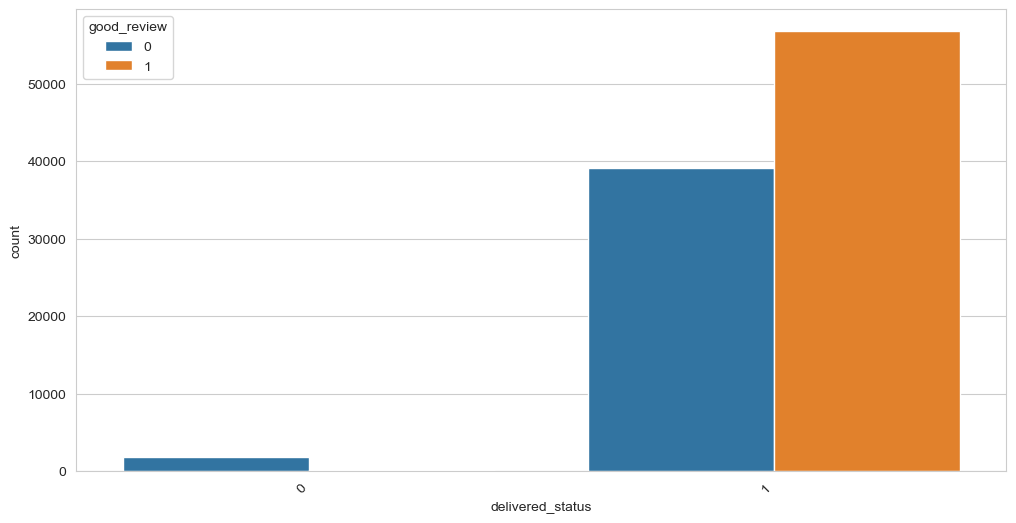

In [22]:
variable_exploration(data, 'delivered_status')

In [23]:
# =============================================================================
# DROPPING DELIVERED_STATUS
# =============================================================================

data = data.drop(columns = 'delivered_status')

print("✅ delivered_status variable was dropped")

✅ delivered_status variable was dropped


#### Customer_state

**Analysis findings**:
- Southeast: ~70% of orders
- South: ~15% of orders
- Northeast: ~10% of orders

**Transformation decision**:
- Central-West and North regions which together cover less than 10% of orders are grouped into "Other" 

**Rationale**: 
- Reducing dimensionality from 5 to 4 entries while preserving major market segments

,Count,Percentage of Total,Cumulative percentage
customer_state,,,
Southeast,67170,68.599616,68.599616
South,13968,14.265289,82.864905
Northeast,9246,9.442788,92.307692
Central-West,5712,5.833572,98.141264
North,1820,1.858736,100.000000


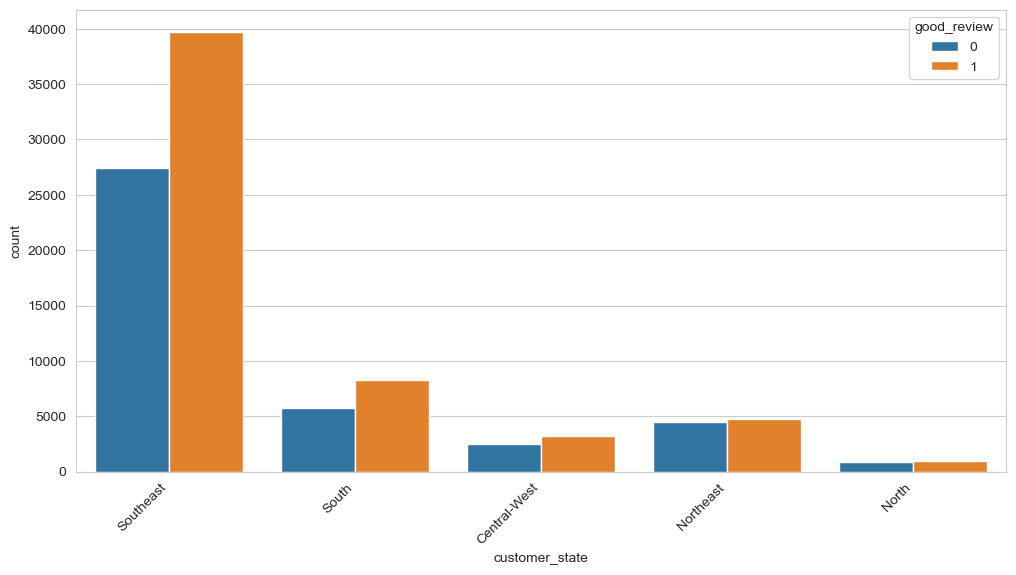

In [25]:
variable_exploration(data, 'customer_state')

,Count,Percentage of Total,Cumulative percentage
customer_state,,,
Southeast,67170,68.599616,68.599616
South,13968,14.265289,82.864905
Northeast,9246,9.442788,92.307692
Other,7532,7.692308,100.000000


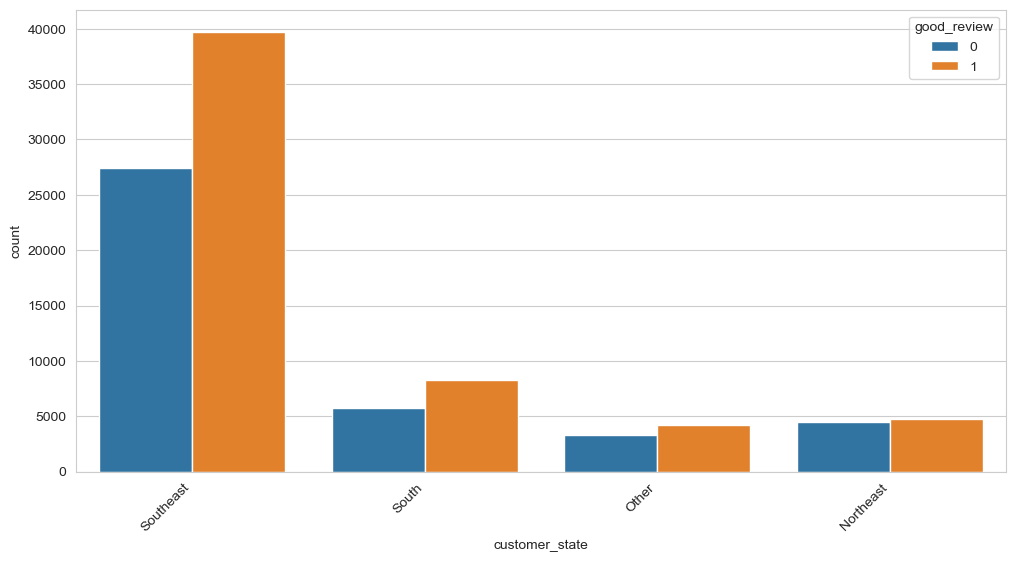

In [26]:
# =============================================================================
# TRANSFORMING CUSTOMER_STATE
# =============================================================================

data["customer_state"] = data["customer_state"].replace({
    "Central-West" : "Other",
    "North" : "Other"
})

variable_exploration(data, 'customer_state')

#### Seller_state

**Analysis findings**:
- Southeast: ~84% of orders
- South: ~13% of orders

**Transformation decision**:
- Northeast, Central-West and North regions which together cover less than ~3% of orders are grouped into "Other" 

**Rationale**: 
- Reducing dimensionality from 5 to 3 entries while preserving major market segments

,Count,Percentage of Total,Cumulative percentage
seller_state,,,
Southeast,81786,83.526696,83.526696
South,13101,13.379836,96.906532
Northeast,1543,1.575841,98.482373
Central-West,1460,1.491074,99.973447
North,26,0.026553,100.000000


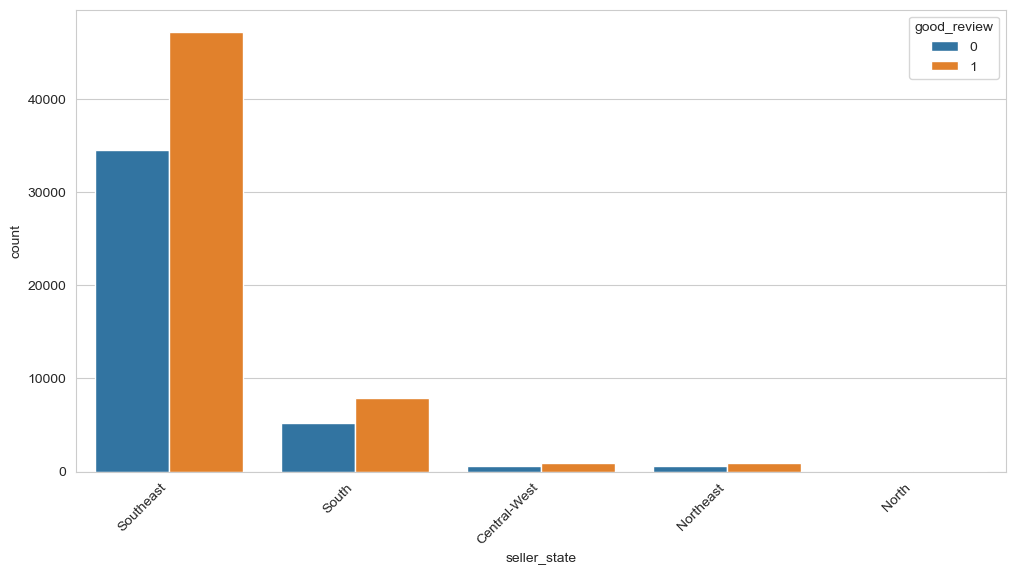

In [28]:
variable_exploration(data, 'seller_state')

,Count,Percentage of Total,Cumulative percentage
seller_state,,,
Southeast,81786,83.526696,83.526696
South,13101,13.379836,96.906532
Other,3029,3.093468,100.000000


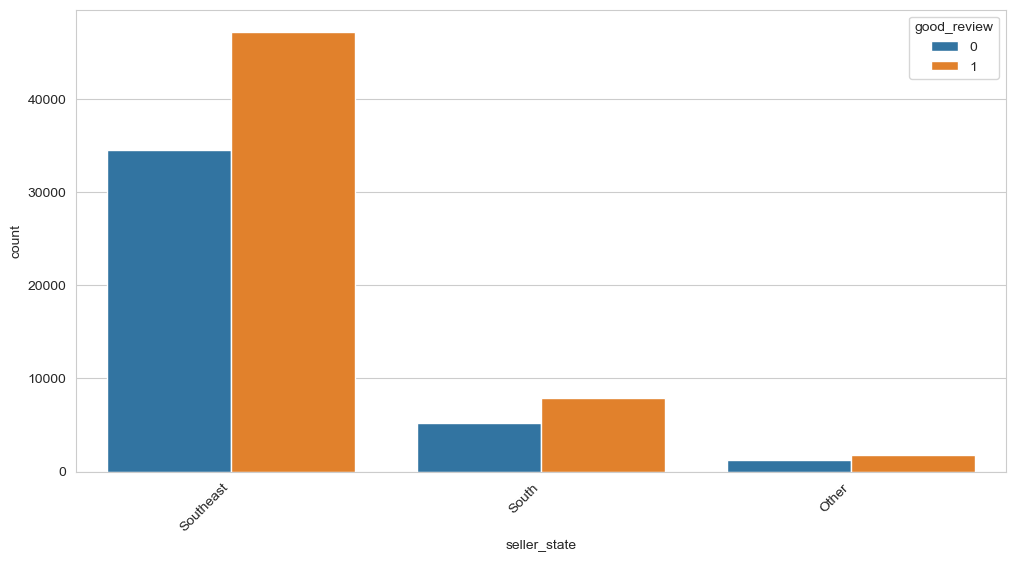

In [29]:
# =============================================================================
# TRANSFORMING CUSTOMER_STATE
# =============================================================================

data["seller_state"] = data["seller_state"].replace({
    "Northeast" : "Other",
    "Central-West" : "Other",
    "North" : "Other"
})

variable_exploration(data, 'seller_state')

#### Number_payments

**Analysis findings**:
- 97% of orders were payed for in just one payment

**Transformation decision**:
- **DROPPED** - Insufficient variance for prediction: polarized features add no discriminative power

**Rationale**: 
- Features with >95% concentration in single value provide minimal information gain for tree-based models

,Count,Percentage of Total,Cumulative percentage
number_payments,,,
1.0,95006,97.028065,97.028065
2.0,2342,2.391846,99.419911
3.0,297,0.303321,99.723232
4.0,106,0.108256,99.831488
5.0,51,0.052085,99.883574
6.0,35,0.035745,99.919319
7.0,28,0.028596,99.947915
8.0,10,0.010213,99.958127
11.0,8,0.008170,99.966298


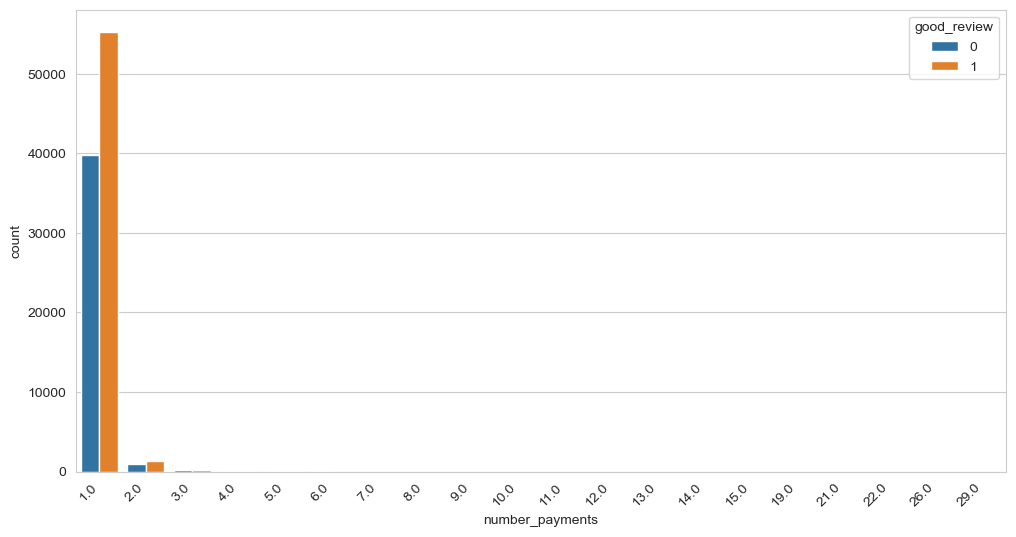

In [31]:
variable_exploration(data, 'number_payments')

In [32]:
# =============================================================================
# DROPPING DELIVERED_STATUS
# =============================================================================

data = data.drop(columns = 'number_payments')

print("✅ number_payments variable was dropped")

✅ number_payments variable was dropped


#### Payment_type

**Analysis findings**:
- Credit card: ~75% of orders
- Boleto: ~20% of orders

**Transformation decision**:
- Voucher and Debit card which together cover less than 5% of orders are grouped into "Other" 

**Rationale**: 
- Reducing dimensionality from 4 to 3 entries while preserving major market segments

,Count,Percentage of Total,Cumulative percentage
payment_type,,,
credit_card,73907,75.480003,75.480003
boleto,19471,19.885412,95.365415
voucher,3024,3.088361,98.453777
debit_card,1514,1.546223,100.000000


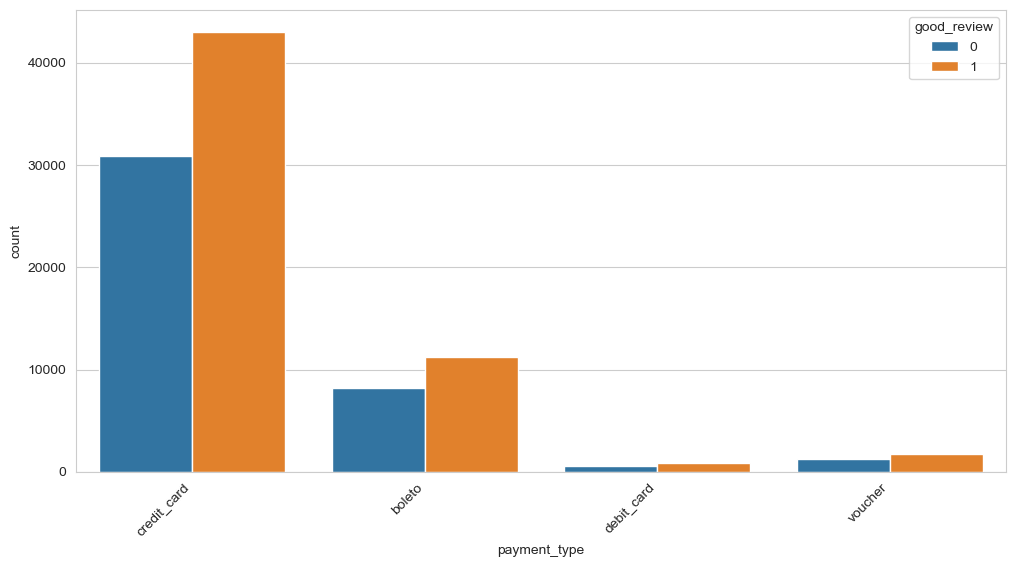

In [34]:
variable_exploration(data, 'payment_type')

,Count,Percentage of Total,Cumulative percentage
payment_type,,,
credit_card,73907,75.480003,75.480003
boleto,19471,19.885412,95.365415
Other,4538,4.634585,100.000000


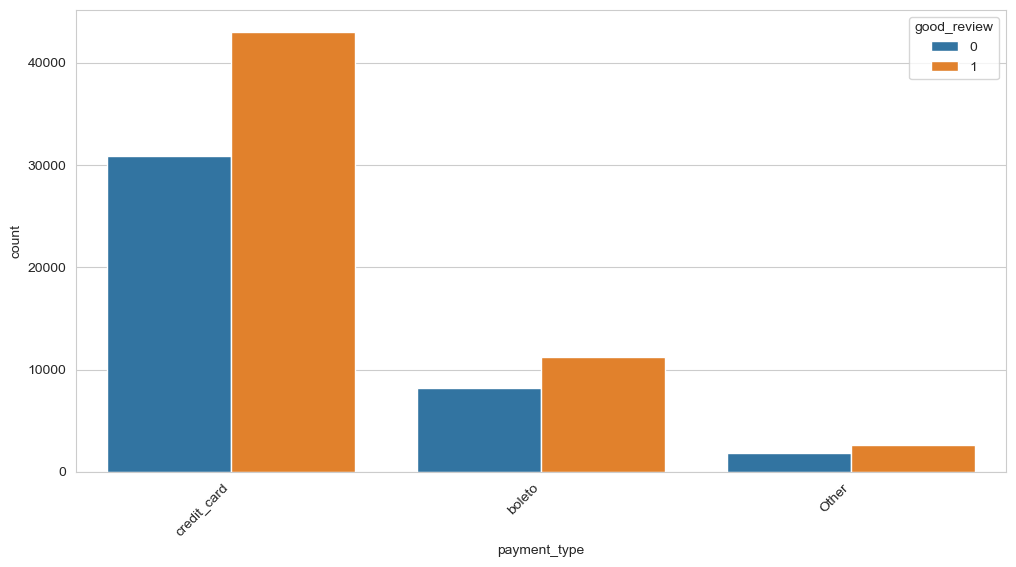

In [35]:
# =============================================================================
# TRANSFORMING PAYMENT_TYPE
# =============================================================================

data["payment_type"] = data["payment_type"].replace({
    "voucher" : "Other",
    "debit_card" : "Other"
}) 

variable_exploration(data, 'payment_type')

#### Number_items

**Analysis findings**:
- 1 item: ~90% of orders
- 2 items: ~8% of orders

**Transformation decision**:
- No transformation 

**Rationale**: 
- Considered binary split but not optimal for tree-based model (can find optimal split point automatically)

,Count,Percentage of Total,Cumulative percentage
number_items,,,
1.0,88227,90.104784,90.104784
2.0,7440,7.598350,97.703133
3.0,1299,1.326647,99.029781
4.0,497,0.507578,99.537359
5.0,204,0.208342,99.745700
6.0,192,0.196086,99.941787
7.0,22,0.022468,99.964255
8.0,8,0.008170,99.972425
10.0,8,0.008170,99.980596


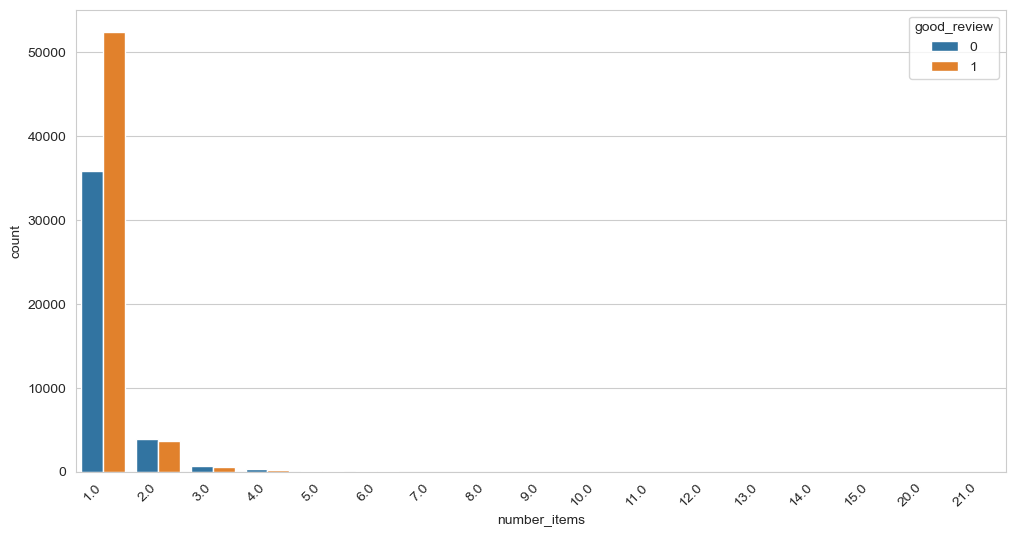

In [37]:
variable_exploration(data, 'number_items')

#### Product_category

**Analysis findings**:
- Top category is Home & Decortaion, with 26% of orders
- Each category groups at least 5% of orders, apart from "Unknown" which groups less than 2%

**Transformation decision**:
- No transformation 

**Rationale**: 
- Distribution is varied, grouping further would result in loss of information

,Count,Percentage of Total,Cumulative percentage
product_category_name_english,,,
Home and Decoration,25496,26.038645,26.038645
Electronics and Technology,19542,19.957923,45.996568
Fashion and Personal Care,18114,18.499530,64.496099
"Leisure, Toys and Arts",14306,14.610482,79.106581
Miscellaneous and Other Items,12780,13.052004,92.158585
Tools and Construction,6274,6.407533,98.566118
Unknown,1404,1.433882,100.000000


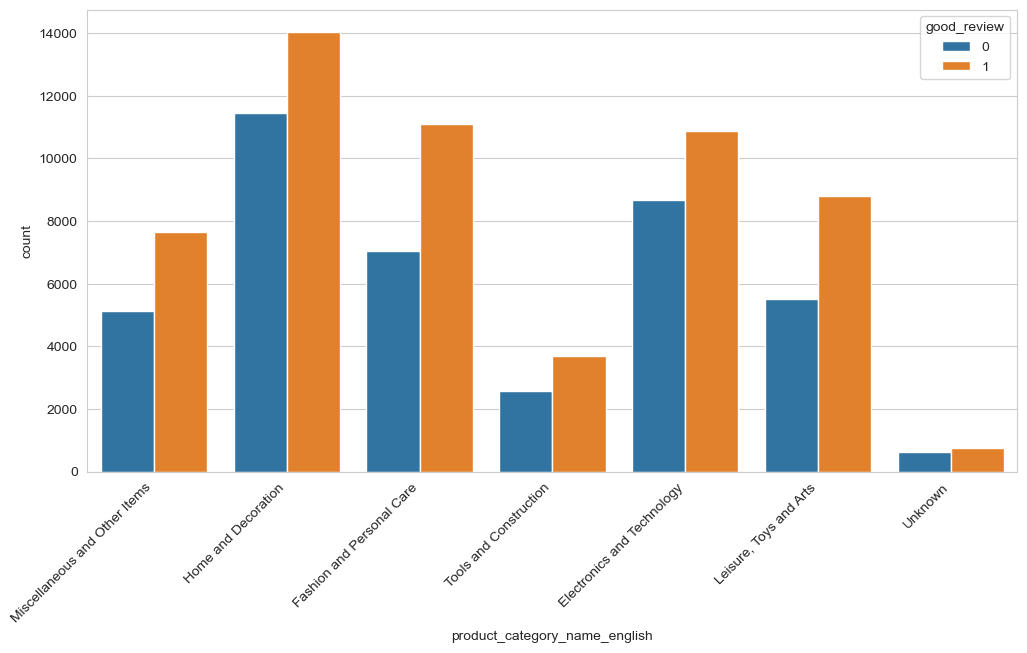

In [39]:
variable_exploration(data, 'product_category_name_english')

#### Product_photos_qty

**Analysis findings**:
- 1 photo: ~50% of orders
- 2 photos: ~20% of orders
- 3 photos: ~10% of orders
- 4-6 photos: ~15% of orders total
- the rest: 0-1% of orders

**Transformation decision**:
- No transformation 

**Rationale**: 
- Considered grouping into categories but not optimal for tree-based model (can find optimal split point automatically)

,Count,Percentage of Total,Cumulative percentage
product_photos_qty,,,
1.0,47655,48.669268,48.669268
2.0,19058,19.463622,68.132889
3.0,11098,11.334205,79.467094
4.0,7522,7.682095,87.149189
5.0,4945,5.050247,92.199436
6.0,3377,3.448875,95.648311
0.0,1404,1.433882,97.082193
7.0,1404,1.433882,98.516075
8.0,683,0.697537,99.213612


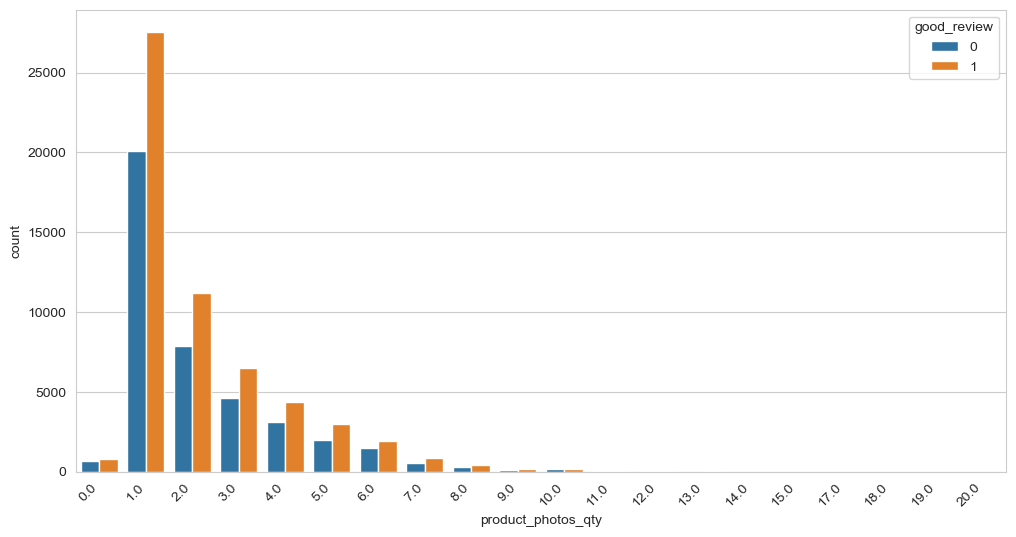

In [41]:
variable_exploration(data, 'product_photos_qty')

### Numerical variables: skewness & outliers analysis

Variables that will be studied in this section:
- `waiting_time`;
- `payment_value_sum`;
- `total_price`;
- `total_freight_value`;
- `product_weight_`;
- `product_length_cm`;
- `product_height_cm`;
- `product_width_cm`;
- `product_description_lenght`.

**Analysis findings:**
- All variables' distribution appear higly to extremely skewed, with moderate to high outliers.

**Transformations:**
- Transformation to logarithmic scale was considered but eventually no transformations were applied.
 
**Rationale:**
- Tree models are robust to skewness and ouliers;
- Values in original scale have better interpretability.

In [43]:
# =============================================================================
# IDENTIFYING CONTINUOUS NUMERICAL VARIABLES
# =============================================================================

for col in data:
    if data[col].nunique() >= 50:
        print(f'{col}: {type(data.loc[0,col])}, {data[col].nunique()} unique values.')

review_date: <class 'pandas._libs.tslibs.timestamps.Timestamp'>, 711 unique values.
order_purchase_timestamp: <class 'pandas._libs.tslibs.timestamps.Timestamp'>, 615 unique values.
waiting_time: <class 'numpy.int64'>, 142 unique values.
payment_value_sum: <class 'numpy.float64'>, 27474 unique values.
total_price: <class 'numpy.float64'>, 7587 unique values.
total_freight_value: <class 'numpy.float64'>, 7666 unique values.
product_weight_g: <class 'numpy.float64'>, 2188 unique values.
product_length_cm: <class 'numpy.float64'>, 99 unique values.
product_height_cm: <class 'numpy.float64'>, 102 unique values.
product_width_cm: <class 'numpy.float64'>, 95 unique values.
product_description_lenght: <class 'numpy.float64'>, 2951 unique values.


In [44]:
# =============================================================================
# DEFINING CONTINUOUS VARIABLE EXPLORATION FUNCTION
# =============================================================================

def cont_variable_exploration(db, column_name):
    
    # Calculate descriptive statistics
    summary = db[column_name].describe().to_frame(name='Value')
    summary.loc['Skewness'] = db[column_name].skew()
    
    # Outlier detection (IQR method)
    Q1 = summary.loc['25%', 'Value']
    Q3 = summary.loc['75%', 'Value']
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = db[(db[column_name] < lower_bound) | (db[column_name] > upper_bound)]
    outlier_pct = (len(outliers) / len(db)) * 100
    
    # Display summary
    print("=" * 60)
    print(f"  {column_name.upper()}")
    print("=" * 60)
    print(summary.to_string())
    print(f"\n⚠️  Outliers: {len(outliers)} ({outlier_pct:.2f}%)")
    
    # Skewness interpretation
    skewness = summary.loc['Skewness', 'Value']
    if abs(skewness) > 1:
        print(f"💡 Highly skewed")
    elif abs(skewness) > 0.5:
        print(f"💡 Moderately skewed")
    else:
        print(f"✅ Approximately symmetric distribution")
    print("=" * 60)
      
    
    # Distribution by review score
    sns.histplot(data=db, x=column_name, hue='good_review', 
                 kde=True, alpha=0.6)
    plt.show()

print("✅ Function defined successfully")

✅ Function defined successfully


#### Waiting_time

  WAITING_TIME
                 Value
count     97916.000000
mean         17.305323
std          34.173294
min           0.000000
25%           7.000000
50%          10.000000
75%          16.000000
max         240.000000
Skewness      5.942353

⚠️  Outliers: 6696 (6.84%)
💡 Highly skewed


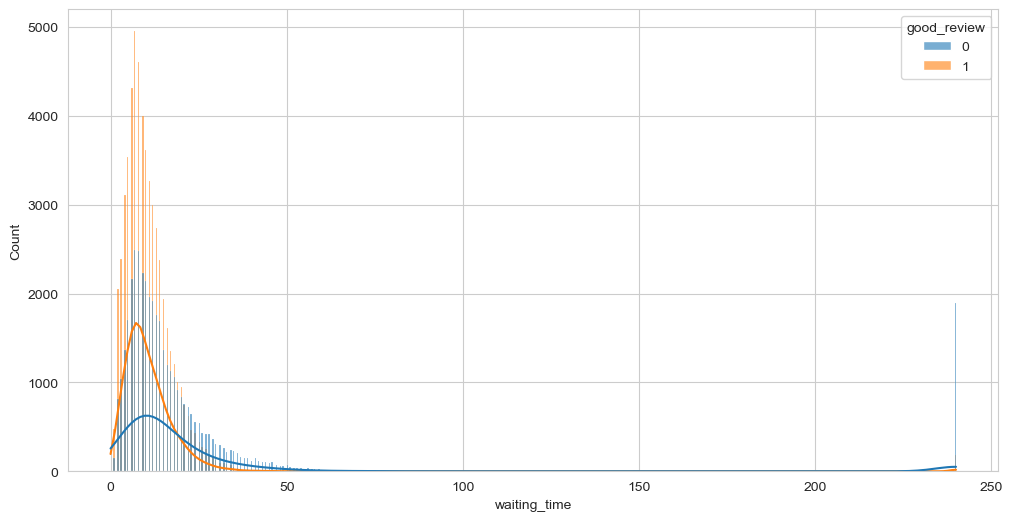

In [46]:
cont_variable_exploration(data, 'waiting_time')

#### Payment, Price & Freight

  PAYMENT_VALUE_SUM
                 Value
count     97916.000000
mean        160.367686
std         219.286727
min           9.590000
25%          61.930000
50%         105.280000
75%         176.760000
max       13664.080000
Skewness      9.105404

⚠️  Outliers: 7717 (7.88%)
💡 Highly skewed


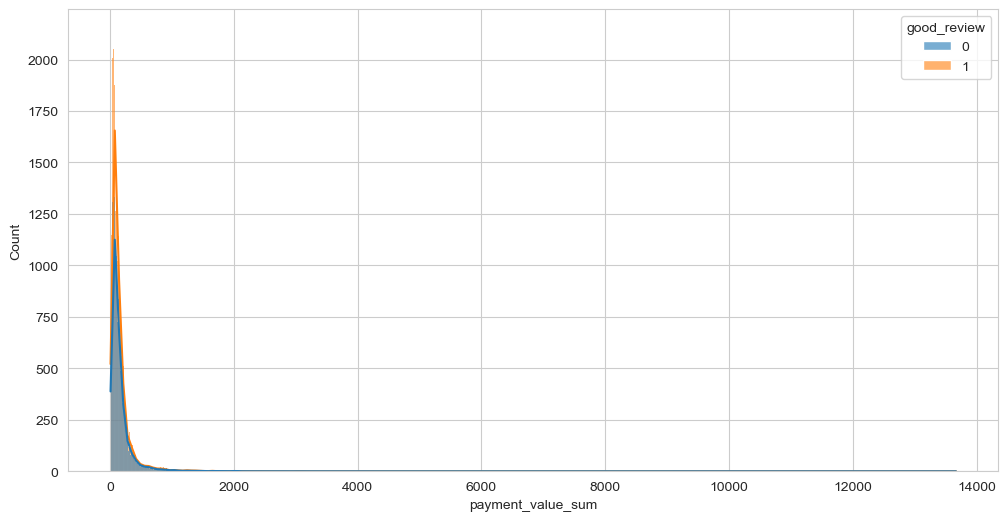

In [48]:
cont_variable_exploration(data, 'payment_value_sum')

  TOTAL_PRICE
                 Value
count     97916.000000
mean        137.534315
std         209.483686
min           0.850000
25%          45.900000
50%          86.900000
75%         149.900000
max       13440.000000
Skewness      9.605547

⚠️  Outliers: 7841 (8.01%)
💡 Highly skewed


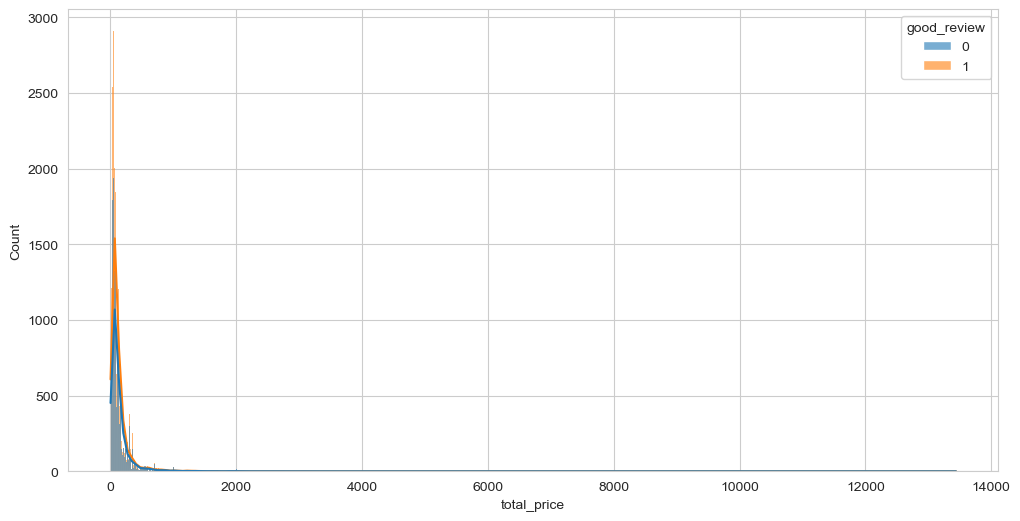

In [49]:
cont_variable_exploration(data, 'total_price')

  TOTAL_FREIGHT_VALUE
                 Value
count     97916.000000
mean         22.804160
std          21.621084
min           0.000000
25%          13.840000
50%          17.160000
75%          24.010000
max        1794.960000
Skewness     12.131137

⚠️  Outliers: 9870 (10.08%)
💡 Highly skewed


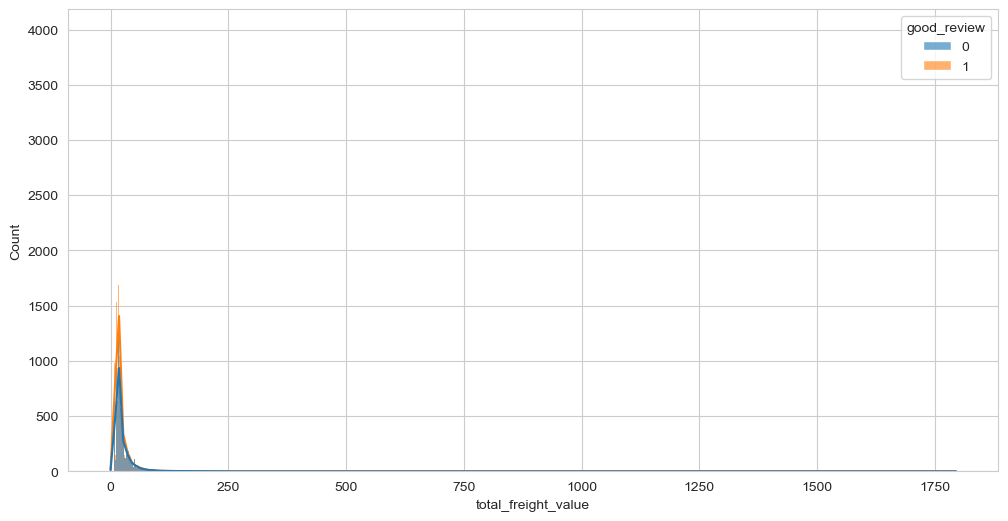

In [50]:
cont_variable_exploration(data, 'total_freight_value')

#### Product weight, length, height, width

  PRODUCT_WEIGHT_G
                 Value
count     97916.000000
mean       2122.457984
std        3786.517282
min           0.000000
25%         300.000000
50%         700.000000
75%        1825.000000
max       40425.000000
Skewness      3.585533

⚠️  Outliers: 13913 (14.21%)
💡 Highly skewed


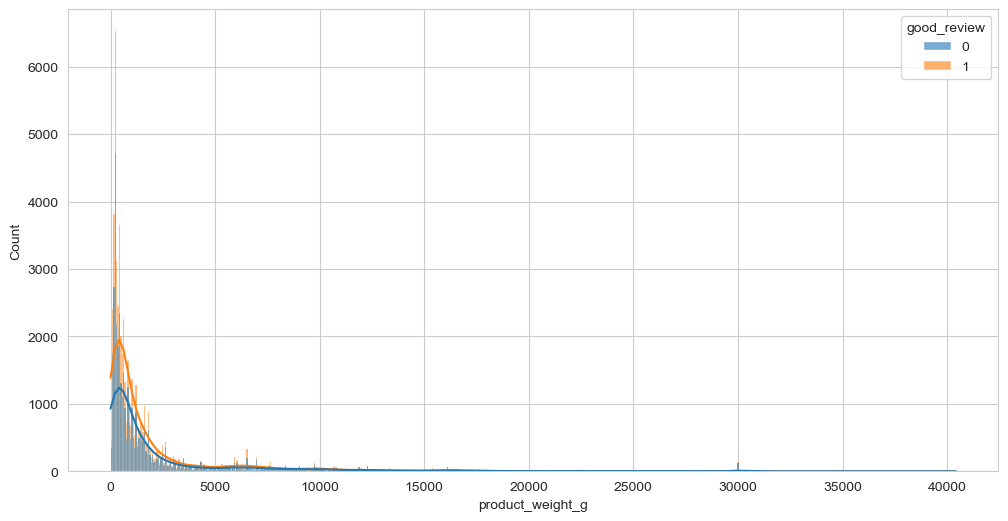

In [52]:
cont_variable_exploration(data, 'product_weight_g')

  PRODUCT_LENGTH_CM
                 Value
count     97916.000000
mean         30.208168
std          16.188251
min           7.000000
25%          18.000000
50%          25.000000
75%          38.000000
max         105.000000
Skewness      1.761761

⚠️  Outliers: 3199 (3.27%)
💡 Highly skewed


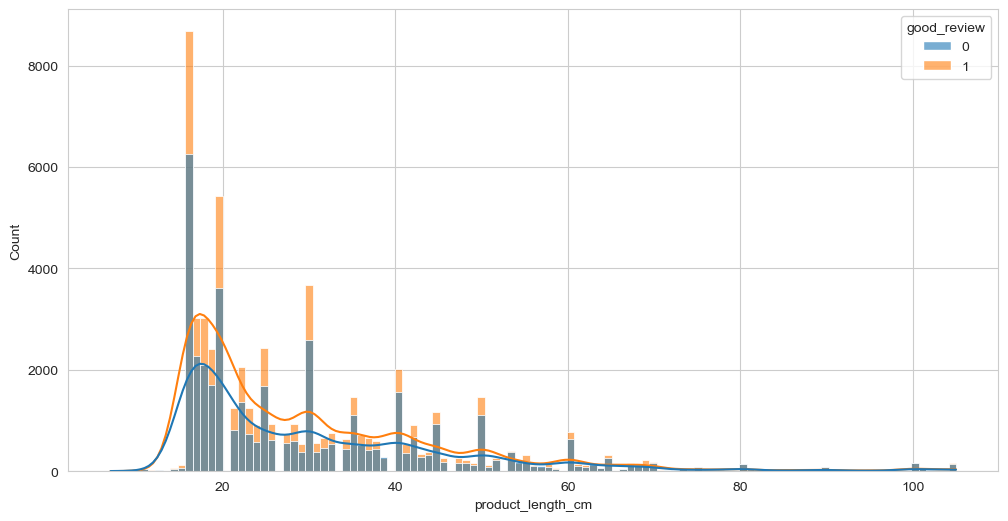

In [53]:
cont_variable_exploration(data, 'product_length_cm')

  PRODUCT_HEIGHT_CM
                 Value
count     97916.000000
mean         16.573522
std          13.377268
min           2.000000
25%           8.000000
50%          13.000000
75%          20.000000
max         105.000000
Skewness      2.261073

⚠️  Outliers: 6661 (6.80%)
💡 Highly skewed


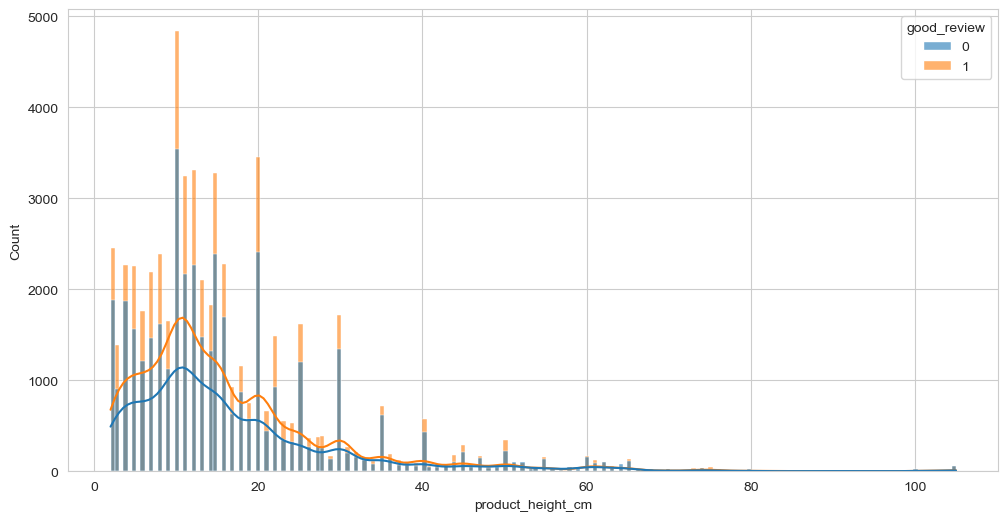

In [54]:
cont_variable_exploration(data, 'product_height_cm')

  PRODUCT_WIDTH_CM
                 Value
count     97916.000000
mean         23.113812
std          11.784437
min           6.000000
25%          15.000000
50%          20.000000
75%          30.000000
max         118.000000
Skewness      1.709036

⚠️  Outliers: 2285 (2.33%)
💡 Highly skewed


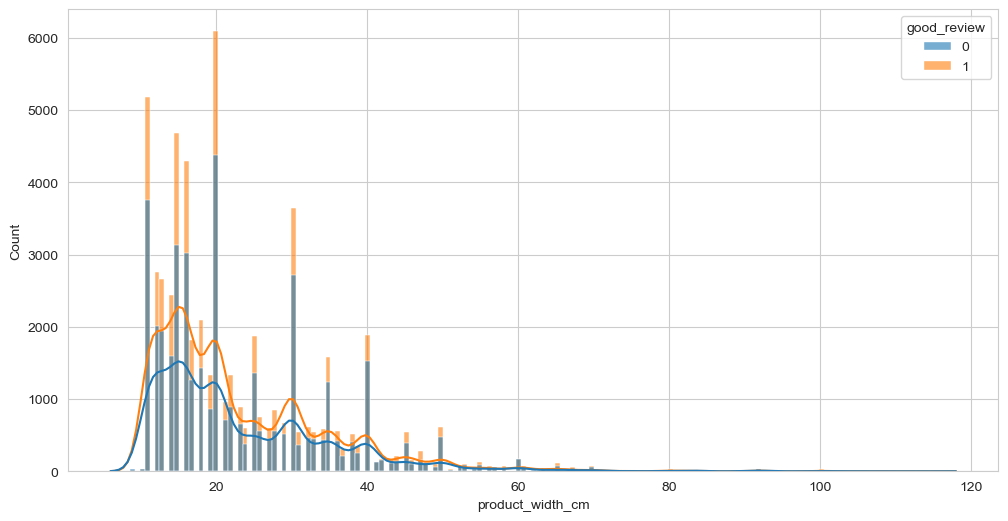

In [55]:
cont_variable_exploration(data, 'product_width_cm')

#### Product_description_length

  PAYMENT_VALUE_SUM
                 Value
count     97916.000000
mean        160.367686
std         219.286727
min           9.590000
25%          61.930000
50%         105.280000
75%         176.760000
max       13664.080000
Skewness      9.105404

⚠️  Outliers: 7717 (7.88%)
💡 Highly skewed


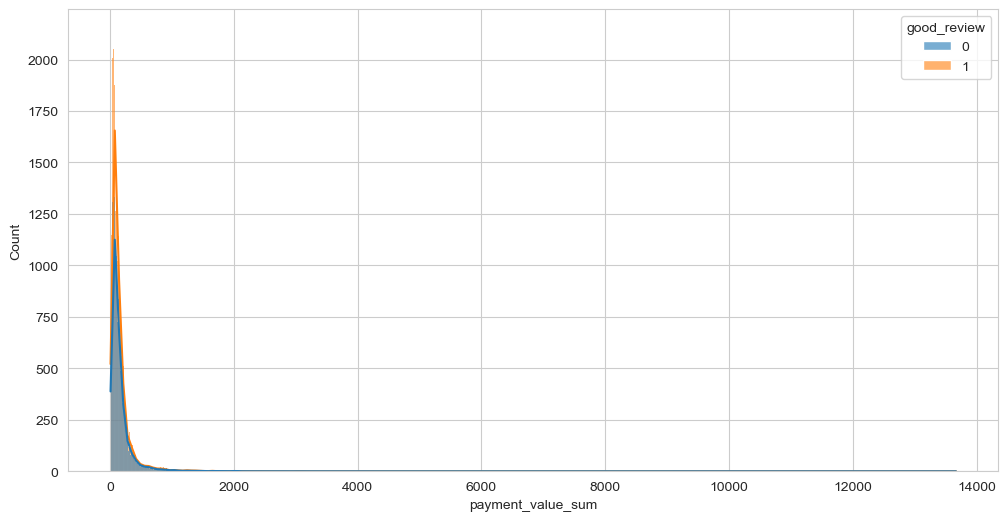

In [57]:
cont_variable_exploration(data, 'payment_value_sum')

### Dates feature engineering

#### Review date

**Transformations:**
- Calculate time between purchase date and review date to evaluate possible impact on review score

**Rationale:**
- This measure might capture an hidden factor

  REVIEW_DELAY
              Value
count       97916.0
mean      15.817711
std       12.581184
min           -39.0
25%             9.0
50%            13.0
75%            20.0
max           528.0
Skewness  11.595543

⚠️  Outliers: 2577 (2.63%)
💡 Highly skewed


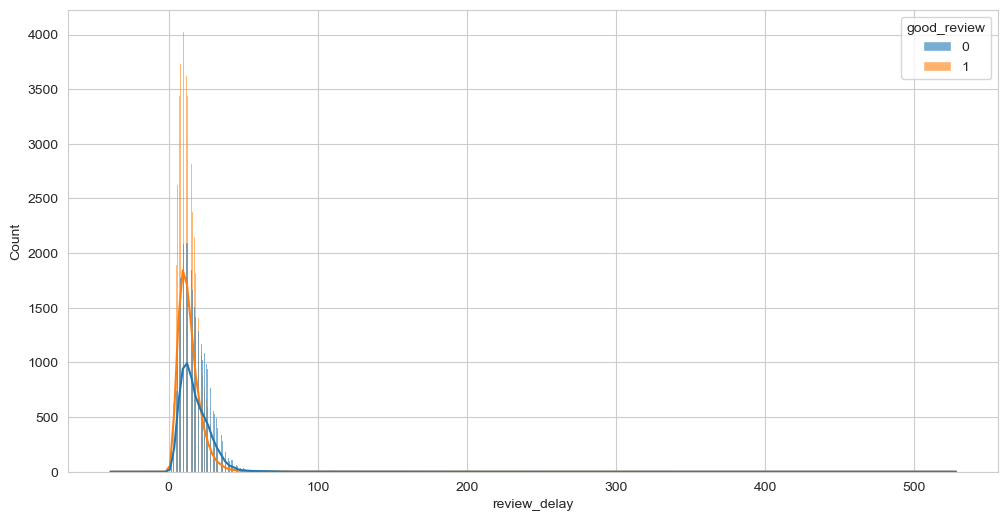

In [60]:
# =============================================================================
# CALCULATING REVIEW DELAY
# =============================================================================

# Calculate the new measure
data = data.assign(
    review_delay = (data["review_date"] - data["order_purchase_timestamp"]).dt.days.astype("Int64")
)

# Drop original column
data = data.drop(columns = "review_date")

# Analyze new measure
cont_variable_exploration(data, 'review_delay')

#### Purchase date

**Transformations:**
- Create a seasonality variable from purchase date.

**Rationale:**
- This measure might capture an hidden factor, easier to interpret than original dates.

,Count,Percentage of Total,Cumulative percentage
order_purchase_season,,,
Winter,30176,30.818252,30.818252
Fall,29443,30.069652,60.887904
Summer,21862,22.327301,83.215205
Spring,16435,16.784795,100.000000


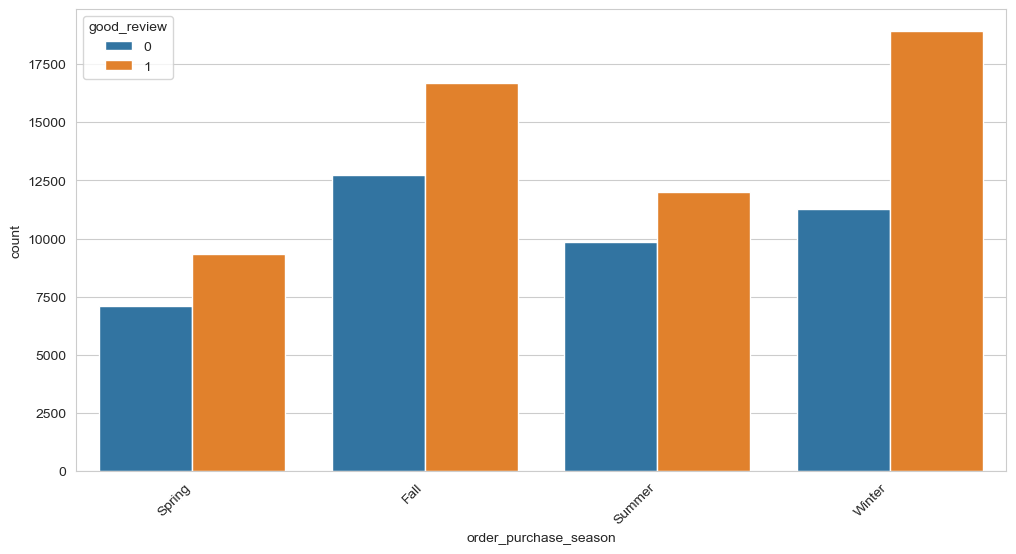

In [62]:
# =============================================================================
# CALCULATING PURCHASE SEASON
# =============================================================================

# Creating purchase_season variable
data["order_purchase_season"] = np.where(
    data["order_purchase_timestamp"].dt.month.isin([3,4,5]),
    "Fall",
    np.where(
        data["order_purchase_timestamp"].dt.month.isin([6,7,8]),
        "Winter",
        np.where(
            data["order_purchase_timestamp"].dt.month.isin([9,10,11]),
            "Spring",
            "Summer"
        )
    )
)

# Dropping original column
data = data.drop(columns = "order_purchase_timestamp")

# Analyzing new measure
variable_exploration(data, 'order_purchase_season')

AHORA FALTA_

2. Correlación
3. Dummies
4. Train y Test
5. Modelo

## Multicolinearity analysis

Multicolinearity is analyzed and handled to improve efficiency and reduce redundancy.

**Approach**:
1. Correlation matrix visualization
2. Variance Inflation Factor (VIF) calculation
3. Feature consolidation where VIF > 10

### Correlation matrix

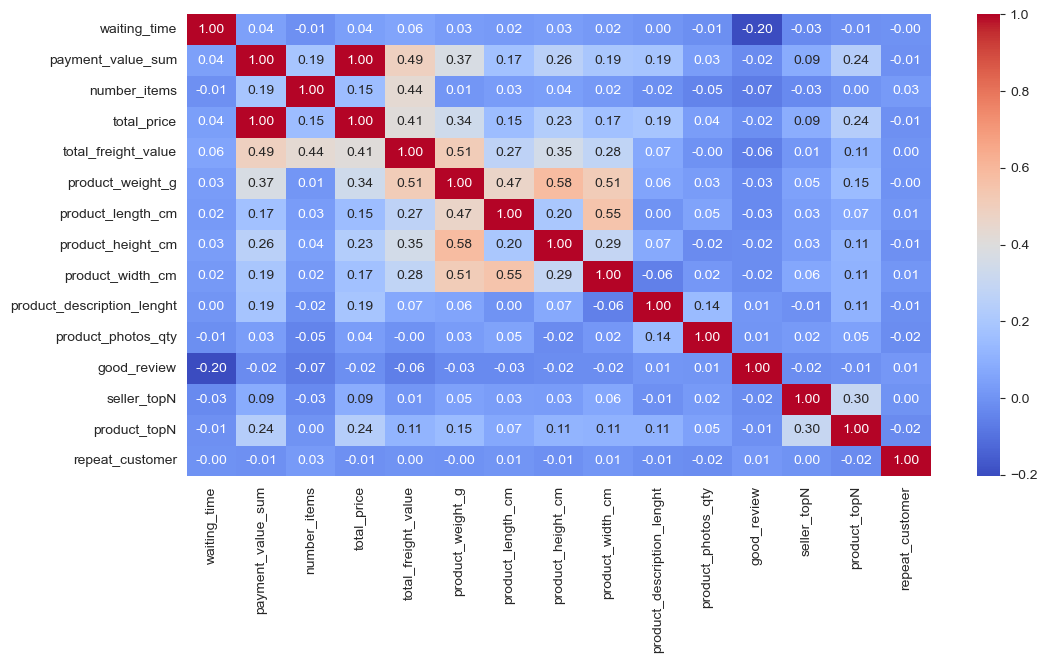


⚠️  HIGH CORRELATION PAIRS (|r| > 0.8):
   payment_value_sum ↔ total_price: r = 0.996


In [66]:
# =============================================================================
# VISUALIZING CORRELATION MATRIX
# =============================================================================

# Creating a list of numerical variables
col_num = []

for i in data.columns:
    dtype = data[i].dtypes
    if dtype == np.int64 or dtype == np.float64 :
        col_num.append(i)

# Creating a dataset containing only numerical variables
data_num = data.loc[:, col_num]

# Computing the correlation matrix
correlation_matrix = data_num.corr()

# Visualazing
sns.heatmap(correlation_matrix, cmap = "coolwarm", annot = True, fmt='.2f')
plt.show()

# Identify high correlations
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print("\n⚠️  HIGH CORRELATION PAIRS (|r| > 0.8):")
    for feat1, feat2, corr in high_corr_pairs:
        print(f"   {feat1} ↔ {feat2}: r = {corr:.3f}")
else:
    print("\n✅ No correlation pairs exceed |r| = 0.8")

### Variance Inflation Factor

**VIF Interpretation**:
- VIF = 1: No correlation with other features
- VIF = 1-5: Moderate correlation (acceptable)
- VIF = 5-10: High correlation (consider removing)
- VIF > 10: Severe multicollinearity (remove)

In [68]:
# =============================================================================
# VIF CALCULATION
# =============================================================================

# Calculating VIF
n_columns = data_num.shape[1]
vif_results = []

for i in range(1, n_columns):
    VIF = variance_inflation_factor(data_num, i)
    col = data_num.columns[i]
    vif_results.append((col, VIF))
    print(f"{col}: {VIF}")

# Flagging high VIF features
high_vif = [col for col, vif in vif_results if vif > 10]
if high_vif:
    print(f"\n⚠️  Features with VIF > 10: {', '.join(high_vif)}")
else:
    print("\n✅ All features have acceptable VIF (< 10)")

payment_value_sum: 57529.8436860119
number_items: 5.804788872586161
total_price: 48954.740470291596
total_freight_value: 775.0447924099217
product_weight_g: 3.040351925018941
product_length_cm: 6.570210824488921
product_height_cm: 3.6686624858650676
product_width_cm: 7.385812850195238
product_description_lenght: 2.4514913833755543
product_photos_qty: 2.510390401037212
good_review: 2.2356452288579787
seller_topN: 3.8531598147967228
product_topN: 3.0823783334757704
repeat_customer: 1.035243127621171

⚠️  Features with VIF > 10: payment_value_sum, total_price, total_freight_value


### Feature Consolidation: Keeping only one payment feature

**Problem highlighted:**
- Financial features are strongly correlated

**Solution:**
- Keeping only payment_value feature as it sums price and freight.

In [70]:
# =============================================================================
# ANALYZING VIF AFTER DROPPING REDUNDANT FEATURES
# =============================================================================

# Dropping price and freight from numerical dataset
data_num = data_num.drop(columns = ['total_price', 'total_freight_value'])

# Calculating VIF
n_columns = data_num.shape[1]
vif_results = []

for i in range(1, n_columns):
    VIF = variance_inflation_factor(data_num, i)
    col = data_num.columns[i]
    vif_results.append((col, VIF))
    print(f"{col}: {VIF}")

# Flagging high VIF variables
high_vif = [col for col, vif in vif_results if vif > 10]
if high_vif:
    print(f"\n⚠️  Features with VIF > 10: {', '.join(high_vif)}")
else:
    print("\n✅ All features have acceptable VIF (< 10)")

payment_value_sum: 1.9805433839708215
number_items: 4.413787188944747
product_weight_g: 2.635332974535985
product_length_cm: 6.565931321570189
product_height_cm: 3.664290203947452
product_width_cm: 7.382014303150809
product_description_lenght: 2.4509239427187715
product_photos_qty: 2.5084737127151135
good_review: 2.2323367258009226
seller_topN: 3.843787018723797
product_topN: 3.0810057446128947
repeat_customer: 1.0351624009576135

✅ All features have acceptable VIF (< 10)


In [71]:
# =============================================================================
# DROPPING REDUNDANT FEATURES FROM FINAL DATASET
# =============================================================================

data = data.drop(columns = ['total_price', 'total_freight_value'])
print('✅ price and freight features are removed from the model')

✅ price and freight features are removed from the model


## Final dataset summary

In [73]:
# =============================================================================
# FINAL DATASET SUMMARY
# =============================================================================

print("=" * 70)
print("  FINAL DATASET FOR MODELING")
print("=" * 70)
print(f"\n📊 DIMENSIONS")
print(f"   Samples: {data.shape[0]:,}")
print(f"   Features: {data.shape[1]}")

print(f"\n📁 FEATURE BREAKDOWN")
categorical = data.select_dtypes(include=['object']).columns.tolist()
numerical = data.select_dtypes(include=[np.number]).columns.tolist()
numerical = [col for col in numerical if col != 'good_review']  # Exclude target

print(f"   Categorical features: {len(categorical)}")
for cat in categorical:
    print(f"      - {cat}: {data[cat].nunique()} categories")

print(f"   Numerical features: {len(numerical)}")
for num in numerical:
    print(f"      - {num}")

print(f"\n🎯 TARGET VARIABLE")
print(f"   good_review (binary):")
print(f"      Class 0 (unsatisfied): {(data['good_review']==0).sum():,} ({(data['good_review']==0).mean()*100:.1f}%)")
print(f"      Class 1 (satisfied): {(data['good_review']==1).sum():,} ({(data['good_review']==1).mean()*100:.1f}%)")

print("=" * 70)

  FINAL DATASET FOR MODELING

📊 DIMENSIONS
   Samples: 97,916
   Features: 19

📁 FEATURE BREAKDOWN
   Categorical features: 5
      - customer_state: 4 categories
      - payment_type: 3 categories
      - product_category_name_english: 7 categories
      - seller_state: 3 categories
      - order_purchase_season: 4 categories
   Numerical features: 13
      - waiting_time
      - payment_value_sum
      - number_items
      - product_weight_g
      - product_length_cm
      - product_height_cm
      - product_width_cm
      - product_description_lenght
      - product_photos_qty
      - seller_topN
      - product_topN
      - repeat_customer
      - review_delay

🎯 TARGET VARIABLE
   good_review (binary):
      Class 0 (unsatisfied): 40,976 (41.8%)
      Class 1 (satisfied): 56,940 (58.2%)


## Predictive Models

**Three Model Comparison**:
   - Decision Tree (baseline, interpretable)
   - Random Forest (ensemble, reduced variance)
   - XGBoost (gradient boosting, state-of-art)

**Evaluation Metrics**:
- **Accuracy**: Overall correct predictions
- **Sensitivity (Recall)**: % of satisfied correctly identified
- **Specificity**: % of unsatisfied correctly identified  
- **F1-Score**: Harmonic mean of precision and recall
- **ROC-AUC**: Area under ROC curve

In [75]:
# =============================================================================
# MODEL EVALUATION HELPER FUNCTION
# =============================================================================

def evaluate_classification_model(model, X_test, y_test, model_name="Model"):
    """
    Comprehensive evaluation of classification model
    
    Parameters:
    -----------
    model : fitted classifier
        Trained sklearn-compatible model
    X_test : array-like
        Test features
    y_test : array-like
        Test labels
    model_name : str
        Display name for model
        
    Returns:
    --------
    dict : evaluation metrics
    """
    
    # Generate predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'sensitivity': TP / (TP + FN) if (TP + FN) > 0 else 0,
        'specificity': TN / (TN + FP) if (TN + FP) > 0 else 0,
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    # Display results
    print("=" * 70)
    print(f"  {model_name.upper()} - EVALUATION RESULTS")
    print("=" * 70)
    
    print(f"\n📊 CLASSIFICATION METRICS")
    print(f"   Accuracy:     {metrics['accuracy']:.4f}")
    print(f"   F1-Score:     {metrics['f1_score']:.4f}")
    print(f"   ROC-AUC:      {metrics['roc_auc']:.4f}")
    
    print(f"\n🎯 SENSITIVITY & SPECIFICITY")
    print(f"   Sensitivity (Recall):  {metrics['sensitivity']:.4f}")
    print(f"      → {metrics['sensitivity']*100:.1f}% of satisfied customers correctly identified")
    print(f"   Specificity:           {metrics['specificity']:.4f}")
    print(f"      → {metrics['specificity']*100:.1f}% of unsatisfied customers correctly identified")
    
    print(f"\n📈 CONFUSION MATRIX")
    print(f"                Predicted")
    print(f"              0        1")
    print(f"   Actual 0  {TN:5}   {FP:5}   (TN, FP)")
    print(f"          1  {FN:5}   {TP:5}   (FN, TP)")
    
    print("=" * 70 + "\n")
    
    return metrics

print("✅ Evaluation function defined")

✅ Evaluation function defined


### Data Preparation for Modeling

**Approach:**
1. Separating **target variable**
2. **One-Hot Encoding** for categorical features
3. **Train-Test Split** (80/20) with stratification and fixed random state (42) for reproducibility

In [77]:
# =============================================================================
# DATA PREPARATION FOR MODELING
# =============================================================================

# Separating target variable
X = data.drop(columns = "good_review")
y = data["good_review"]

# One hot encoding
X_encoded = pd.get_dummies(X, drop_first = True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,           # Features (after one-hot encoding)
    y,                   # Target variable (good_review: 0/1)
    test_size=0.2,       # 20% held out for testing
    random_state=42,     # Reproducibility
    stratify=y           # Maintain class proportions
)

# Display split statistics
print("="*70)
print("  TRAIN-TEST SPLIT SUMMARY")
print("="*70)

print(f"\n📊 DATASET DIMENSIONS:")
print(f"   Total samples:     {len(X_encoded):,}")
print(f"   Total features:    {X_encoded.shape[1]}")

print(f"\n✂️  SPLIT BREAKDOWN:")
print(f"   Training set:      {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"   Test set:          {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")

print(f"\n⚖️  CLASS DISTRIBUTION:")
print(f"\n   Original Dataset:")
print(f"      Bad reviews (0):  {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")
print(f"      Good reviews (1): {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")

print(f"\n   Training Set:")
print(f"      Bad reviews (0):  {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"      Good reviews (1): {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")

print(f"\n   Test Set:")
print(f"      Bad reviews (0):  {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)")
print(f"      Good reviews (1): {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)")

# Verify stratification worked
train_ratio = (y_train==1).mean()
test_ratio = (y_test==1).mean()
original_ratio = (y==1).mean()

if abs(train_ratio - original_ratio) < 0.01 and abs(test_ratio - original_ratio) < 0.01:
    print(f"\n✅ Stratification successful: Class ratios maintained across splits")
else:
    print(f"\n⚠️  Warning: Class ratios differ slightly from original distribution")

print("="*70)

  TRAIN-TEST SPLIT SUMMARY

📊 DATASET DIMENSIONS:
   Total samples:     97,916
   Total features:    29

✂️  SPLIT BREAKDOWN:
   Training set:      78,332 samples (80.0%)
   Test set:          19,584 samples (20.0%)

⚖️  CLASS DISTRIBUTION:

   Original Dataset:
      Bad reviews (0):  40,976 (41.8%)
      Good reviews (1): 56,940 (58.2%)

   Training Set:
      Bad reviews (0):  32,780 (41.8%)
      Good reviews (1): 45,552 (58.2%)

   Test Set:
      Bad reviews (0):  8,196 (41.9%)
      Good reviews (1): 11,388 (58.1%)

✅ Stratification successful: Class ratios maintained across splits


In [78]:
X_encoded

,waiting_time,payment_value_sum,number_items,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_description_lenght,product_photos_qty,seller_topN,product_topN,repeat_customer,review_delay,customer_state_Other,customer_state_South,customer_state_Southeast,payment_type_boleto,payment_type_credit_card,product_category_name_english_Fashion and Personal Care,product_category_name_english_Home and Decoration,"product_category_name_english_Leisure, Toys and Arts",product_category_name_english_Miscellaneous and Other Items,product_category_name_english_Tools and Construction,product_category_name_english_Unknown,seller_state_South,seller_state_Southeast,order_purchase_season_Spring,order_purchase_season_Summer,order_purchase_season_Winter
0,7,72.19,1.0,650.0,28.0,9.0,14.0,598.0,4.0,1,1,0,9,False,False,True,False,True,False,False,False,True,False,False,False,True,True,False,False
1,16,259.83,1.0,30000.0,50.0,30.0,40.0,239.0,2.0,1,0,0,19,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,False
2,8,216.87,1.0,3050.0,33.0,13.0,33.0,695.0,2.0,0,1,0,9,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False
3,6,25.78,1.0,200.0,16.0,10.0,15.0,480.0,1.0,0,0,0,7,False,False,True,False,True,True,False,False,False,False,False,False,True,False,False,True
4,25,218.04,1.0,3750.0,35.0,40.0,30.0,409.0,1.0,0,1,0,27,False,False,True,False,True,False,False,False,False,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97911,17,343.40,1.0,10150.0,89.0,15.0,40.0,1002.0,3.0,1,1,0,21,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False
97912,9,386.53,1.0,8950.0,45.0,26.0,38.0,232.0,1.0,0,1,0,11,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,True
97913,5,116.85,1.0,967.0,21.0,24.0,19.0,869.0,1.0,1,1,0,6,False,False,True,False,True,False,False,True,False,False,False,True,False,True,False,False
97914,2,64.71,1.0,100.0,20.0,20.0,20.0,1306.0,1.0,1,1,0,4,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,True


### Decision Tree Model

#### Defining best depth level

In [81]:
for i in np.arange(1, 50, 5):
    clf = DecisionTreeClassifier(max_depth = i)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{i} -> {np.round(acc,4)}")

1 -> 0.6399
6 -> 0.6488
11 -> 0.6411
16 -> 0.6269
21 -> 0.6095
26 -> 0.5885
31 -> 0.583
36 -> 0.5731
41 -> 0.5752
46 -> 0.5759


In [82]:
for i in np.arange(1, 11):
    clf = DecisionTreeClassifier(max_depth = i)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{i} -> {np.round(acc,4)}")

1 -> 0.6399
2 -> 0.6399
3 -> 0.6441
4 -> 0.6465
5 -> 0.6477
6 -> 0.6488
7 -> 0.6487
8 -> 0.646
9 -> 0.6459
10 -> 0.6438


#### Training the model

Model is trained considering class imbalance.

**Analysis findings:**
- Best accuracy score identified with max_depth level = 6. 
- Results are fairly similar with max_depth levels 4 and 5

**Decision taken:**
- To use max_depth level = 4

**Rationale:**
- Selecting lowest level possible while preserving accuracy reduces overfitting.

In [163]:
# =============================================================================
# DECISION TREE - MODEL TRAINING
# =============================================================================

# Initialize model
clf = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight='balanced'
)

# Train model
clf.fit(X_train, y_train)

print("✅ Decision Tree trained successfully")
print(f"   Tree depth: {clf.get_depth()}")
print(f"   Number of leaves: {clf.get_n_leaves()}")

# Show decision tree
plt.figure(figsize=(20,10))
plot_tree(clf, filled = True, feature_names = X.columns)
plt.show()

✅ Decision Tree trained successfully
   Tree depth: 4
   Number of leaves: 16


#### Model Evaluation

In [255]:
# =============================================================================
# DECISION TREE - MODEL EVALUATION
# =============================================================================

clf_metrics = evaluate_classification_model(clf, X_test, y_test, "Decision Tree")

  DECISION TREE - EVALUATION RESULTS

📊 CLASSIFICATION METRICS
   Accuracy:     0.6318
   F1-Score:     0.7091
   ROC-AUC:      0.6407

🎯 SENSITIVITY & SPECIFICITY
   Sensitivity (Recall):  0.7719
      → 77.2% of satisfied customers correctly identified
   Specificity:           0.4372
      → 43.7% of unsatisfied customers correctly identified

📈 CONFUSION MATRIX
                Predicted
              0        1
   Actual 0   3583    4613   (TN, FP)
          1   2598    8790   (FN, TP)



#### Feature Importance

In [197]:
# =============================================================================
# FEATURE IMPORTANCE EXTRACTION
# =============================================================================

# Get importances from Random Forest
importances = clf.feature_importances_
features = X_encoded.columns

# Create DataFrame
fi_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Display top features
print("=" * 70)
print("  TOP 20 MOST IMPORTANT FEATURES")
print("=" * 70)
print(fi_df.head(20).to_string(index=False))
print("=" * 70)

  TOP 20 MOST IMPORTANT FEATURES
                                                    Feature  Importance
                                               waiting_time    0.865089
                                               number_items    0.090603
                                               review_delay    0.039734
                                          payment_value_sum    0.002931
                                       customer_state_Other    0.001644
                                   payment_type_credit_card    0.000000
                               order_purchase_season_Summer    0.000000
                               order_purchase_season_Spring    0.000000
                                     seller_state_Southeast    0.000000
                                         seller_state_South    0.000000
                      product_category_name_english_Unknown    0.000000
       product_category_name_english_Tools and Construction    0.000000
product_category_name_english_M

### Random Forest Model

#### Defining best depth level

In [180]:
for i in np.arange(1, 50, 5):
    rdf = RandomForestClassifier(max_depth = i)
    rdf.fit(X_train, y_train)
    y_pred = rdf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{i} -> {np.round(acc,4)}")

1 -> 0.6369
6 -> 0.6463
11 -> 0.649
16 -> 0.6495
21 -> 0.6437
26 -> 0.6377
31 -> 0.6317
36 -> 0.6285
41 -> 0.6286
46 -> 0.6289


In [182]:
for i in np.arange(6, 16):
    rdf = DecisionTreeClassifier(max_depth = i)
    rdf.fit(X_train, y_train)
    y_pred = rdf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{i} -> {np.round(acc,4)}")

6 -> 0.6488
7 -> 0.6487
8 -> 0.646
9 -> 0.6459
10 -> 0.6436
11 -> 0.6413
12 -> 0.6395
13 -> 0.6358
14 -> 0.6336
15 -> 0.6325


#### Training the model 

Model is trained considering class imbalance.

**Analysis findings:**
- Best accuracy score identified with max_depth level = 6. 

**Decision taken:**
- To use max_depth level = 6.

**Rationale:**
- Selecting lowest level possible while preserving accuracy reduces overfitting.

In [187]:
# =============================================================================
# RANDOM FOREST - MODEL TRAINING
# =============================================================================
rdf = RandomForestClassifier(max_depth=6, random_state=42, class_weight='balanced')
rdf.fit(X_train, y_train)

y_pred = rdf.predict(X_test)

print("✅ Random Forest trained successfully")
print(f"   Number of trees: {rdf.n_estimators}")
print(f"   Max depth per tree: {rdf.max_depth}")
print(f"   Total features: {rdf.n_features_in_}")

✅ Random Forest trained successfully
   Number of trees: 100
   Max depth per tree: 6
   Total features: 29


#### Model Evaluation

In [259]:
# =============================================================================
# RANDOM FOREST - MODEL EVALUATION
# =============================================================================

rdf_metrics = evaluate_classification_model(rdf, X_test, y_test, "Random Forest")

  RANDOM FOREST - EVALUATION RESULTS

📊 CLASSIFICATION METRICS
   Accuracy:     0.6313
   F1-Score:     0.7099
   ROC-AUC:      0.6473

🎯 SENSITIVITY & SPECIFICITY
   Sensitivity (Recall):  0.7758
      → 77.6% of satisfied customers correctly identified
   Specificity:           0.4305
      → 43.0% of unsatisfied customers correctly identified

📈 CONFUSION MATRIX
                Predicted
              0        1
   Actual 0   3528    4668   (TN, FP)
          1   2553    8835   (FN, TP)



#### Feature Importance

In [195]:
# =============================================================================
# FEATURE IMPORTANCE EXTRACTION
# =============================================================================

# Get importances from Random Forest
importances = rdf.feature_importances_
features = X_encoded.columns

# Create DataFrame
fi_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Display top features
print("=" * 70)
print("  TOP 20 MOST IMPORTANT FEATURES")
print("=" * 70)
print(fi_df.head(20).to_string(index=False))
print("=" * 70)

  TOP 20 MOST IMPORTANT FEATURES
                                                Feature  Importance
                                           waiting_time    0.479320
                                           review_delay    0.336094
                                           number_items    0.053793
                           order_purchase_season_Winter    0.020535
                                      payment_value_sum    0.011730
                                       product_weight_g    0.010286
                             product_description_lenght    0.009899
                                      product_height_cm    0.009625
                                      product_length_cm    0.009271
                               customer_state_Southeast    0.008988
   product_category_name_english_Leisure, Toys and Arts    0.008034
      product_category_name_english_Home and Decoration    0.007703
                                       product_width_cm    0.007135
               

### XGBoost Model

#### Defining best depth level

In [202]:
for i in np.arange(1, 50, 5):
    xgb = XGBClassifier(
        max_depth=i,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{i} -> {np.round(acc, 4)}")

/opt/anaconda3/envs/entorno_python/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:41:55] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


1 -> 0.6488


/opt/anaconda3/envs/entorno_python/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:41:55] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


6 -> 0.6435


/opt/anaconda3/envs/entorno_python/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:41:56] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

36 -> 0.612


/opt/anaconda3/envs/entorno_python/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:42:35] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


41 -> 0.6129


/opt/anaconda3/envs/entorno_python/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:42:44] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


46 -> 0.6115


In [204]:
for i in np.arange(1, 7):
    xgb = XGBClassifier(
        max_depth=i,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    xgb.fit(X_train, y_train)
    y_pred = xgb.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{i} -> {np.round(acc, 4)}")

/opt/anaconda3/envs/entorno_python/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:43:57] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


1 -> 0.6488


/opt/anaconda3/envs/entorno_python/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:43:57] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


2 -> 0.6493


/opt/anaconda3/envs/entorno_python/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:43:58] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

4 -> 0.6469


/opt/anaconda3/envs/entorno_python/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:43:59] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


5 -> 0.6485


/opt/anaconda3/envs/entorno_python/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:44:00] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


6 -> 0.6435


#### Training the model

Model is trained considering class imbalance.

**Analysis findings:**
- Best accuracy score identified with max_depth level = 2 and 3. 

**Decision taken:**
- To use max_depth level = 2.

**Rationale:**
- Selecting lowest level possible while preserving accuracy reduces overfitting.

In [208]:
# =============================================================================
# XGBOOST - MODEL TRAINING
# =============================================================================

# Calculate scale_pos_weight for class balancing
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1")
print(f"   Bad reviews (0): {(y_train == 0).sum():,}")
print(f"   Good reviews (1): {(y_train == 1).sum():,}")

# Initialize model
xgb = XGBClassifier(
    max_depth=3,
    n_estimators=100,
    random_state=42,
    scale_pos_weight=scale_pos_weight, 
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train model
xgb.fit(X_train, y_train)

print("✅ XGBoost trained successfully")
print(f"   Number of boosting rounds: {xgb.n_estimators}")
print(f"   Max depth per tree: {xgb.max_depth}")
print(f"   Scale pos weight: {scale_pos_weight:.2f}")

Class imbalance ratio: 0.72:1
   Bad reviews (0): 32,780
   Good reviews (1): 45,552


/opt/anaconda3/envs/entorno_python/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [11:46:24] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1765326940857/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost trained successfully
   Number of boosting rounds: 100
   Max depth per tree: 3
   Scale pos weight: 0.72


#### Model Evaluation

In [257]:
# =============================================================================
# XGBOOST - MODEL EVALUATION
# =============================================================================

xgb_metrics = evaluate_classification_model(xgb, X_test, y_test, "XG Boost")

  XG BOOST - EVALUATION RESULTS

📊 CLASSIFICATION METRICS
   Accuracy:     0.6435
   F1-Score:     0.7376
   ROC-AUC:      0.6480

🎯 SENSITIVITY & SPECIFICITY
   Sensitivity (Recall):  0.8615
      → 86.2% of satisfied customers correctly identified
   Specificity:           0.3405
      → 34.1% of unsatisfied customers correctly identified

📈 CONFUSION MATRIX
                Predicted
              0        1
   Actual 0   2791    5405   (TN, FP)
          1   1577    9811   (FN, TP)



#### Feature Importance

In [214]:
# =============================================================================
# FEATURE IMPORTANCE EXTRACTION
# =============================================================================

# Get importances from XG Boost
importances = xgb.feature_importances_
features = X_encoded.columns

# Create DataFrame
fi_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Display top features
print("=" * 70)
print("  TOP 20 MOST IMPORTANT FEATURES")
print("=" * 70)
print(fi_df.head(20).to_string(index=False))
print("=" * 70)

  TOP 20 MOST IMPORTANT FEATURES
                                                    Feature  Importance
                                               waiting_time    0.191438
                                               number_items    0.106245
                                               review_delay    0.039403
       product_category_name_english_Leisure, Toys and Arts    0.037056
                                   customer_state_Southeast    0.036881
       product_category_name_english_Tools and Construction    0.033833
          product_category_name_english_Home and Decoration    0.033475
                                     seller_state_Southeast    0.031588
    product_category_name_english_Fashion and Personal Care    0.028930
                                                seller_topN    0.027318
                                          product_height_cm    0.026647
product_category_name_english_Miscellaneous and Other Items    0.026228
                               

### Logistic Regression Model

**Analysis findings:**
- Tree models show acceptable accuracy but low specificity.

**Decision taken:**
- Analyze results using a different model to predict satisfaction: Logistic regression.

**Rationale:**
- Logistic Regression models work well with binary outcomes predictions depending on different factors.

#### Data Preparation for Logistic Regression

Data needs to be scaled for logistic regression model to work optimally.

In [219]:
# =============================================================================
# FEATURE SCALING FOR LOGISTIC REGRESSION
# =============================================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✅ Feature scaling complete")

✅ Feature scaling complete


#### Defining best number of features to select

In [233]:
# Importing libraries
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

#Defining the model
lr = LogisticRegression(max_iter = 100000)

# Finding optimal number of features
n_col = X_train_scaled.shape[1]
for i in range(n_col, 1, -5):
    rfe = RFE(lr, n_features_to_select = i)
    rfe = rfe.fit(X_train_scaled, y_train)

    X_train_final = X_train_scaled.loc[:, rfe.support_]
    X_test_final = X_test_scaled.loc[:, rfe.support_]

    logreg = LogisticRegression(max_iter = 100000)
    logreg.fit(X_train_final, y_train)
    acc = logreg.score(X_test_final, y_test)
    
    print(f"{i}: {np.round(acc, 4)}")

29: 0.6408
24: 0.6409
19: 0.6407
14: 0.641
9: 0.6394
4: 0.6395


In [237]:
#Defining the model
lr = LogisticRegression(max_iter = 100000)

# Finding optimal number of features
n_col = X_train_scaled.shape[1]
for i in range(10, 0, -1):
    rfe = RFE(lr, n_features_to_select = i)
    rfe = rfe.fit(X_train_scaled, y_train)

    X_train_final = X_train_scaled.loc[:, rfe.support_]
    X_test_final = X_test_scaled.loc[:, rfe.support_]

    logreg = LogisticRegression(max_iter = 100000)
    logreg.fit(X_train_final, y_train)
    acc = logreg.score(X_test_final, y_test)
    
    print(f"{i}: {np.round(acc, 4)}")

10: 0.6394
9: 0.6394
8: 0.6408
7: 0.6411
6: 0.6414
5: 0.6409
4: 0.6395
3: 0.6398
2: 0.6404
1: 0.6399


#### Training the model

In [240]:
# =============================================================================
# LOGISTIC REGRESSION - FINAL MODEL WITH RFE
# =============================================================================

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Apply RFE with 6 features
lr_base = LogisticRegression(max_iter=100000, random_state=42, class_weight='balanced')
rfe = RFE(estimator=lr_base, n_features_to_select=6)
rfe.fit(X_train_scaled, y_train)

# Get selected features
selected_features = X_train_scaled.columns[rfe.support_]

# Train final model on selected features
X_train_selected = X_train_scaled.loc[:, rfe.support_]
X_test_selected = X_test_scaled.loc[:, rfe.support_]

logreg = LogisticRegression(max_iter=100000, random_state=42, class_weight='balanced')
logreg.fit(X_train_selected, y_train)

# Predictions
y_pred = logreg.predict(X_test_selected)

print("✅ Logistic Regression trained successfully")
print(f"   Number of features selected: {rfe.n_features_}")
print(f"   Regularization (C): {logreg.C}")
print(f"   Selected features: {list(selected_features)}")

✅ Logistic Regression trained successfully
   Number of features selected: 6
   Regularization (C): 1.0
   Selected features: ['waiting_time', 'number_items', 'review_delay', 'product_category_name_english_Fashion and Personal Care', 'product_category_name_english_Leisure, Toys and Arts', 'order_purchase_season_Winter']


#### Model Evaluation

In [261]:
# =============================================================================
# LOGISTIC REGRESSION - MODEL EVALUATION
# =============================================================================

logreg_metrics = evaluate_classification_model(logreg, X_test_selected, y_test, "Logistic Regression")

  LOGISTIC REGRESSION - EVALUATION RESULTS

📊 CLASSIFICATION METRICS
   Accuracy:     0.6254
   F1-Score:     0.6951
   ROC-AUC:      0.6406

🎯 SENSITIVITY & SPECIFICITY
   Sensitivity (Recall):  0.7345
      → 73.4% of satisfied customers correctly identified
   Specificity:           0.4739
      → 47.4% of unsatisfied customers correctly identified

📈 CONFUSION MATRIX
                Predicted
              0        1
   Actual 0   3884    4312   (TN, FP)
          1   3024    8364   (FN, TP)



#### Feature Importance

In [248]:
# =============================================================================
# LOGISTIC REGRESSION - FEATURE IMPORTANCE
# =============================================================================

# Get coefficients
coefficients = logreg.coef_[0]  # Get coefficients (flat array)
feature_names = X_train_selected.columns

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)  # Absolute value for ranking
}).sort_values('Abs_Coefficient', ascending=False)

print("="*70)
print("  LOGISTIC REGRESSION - FEATURE IMPORTANCE")
print("="*70)
print(importance_df.to_string(index=False))
print("="*70)

print("\n📊 Interpretation:")
print("   Positive coefficient: Feature increases probability of good review")
print("   Negative coefficient: Feature decreases probability of good review")
print("   Larger absolute value: Stronger impact on prediction")

  LOGISTIC REGRESSION - FEATURE IMPORTANCE
                                                Feature  Coefficient  Abs_Coefficient
                                           waiting_time    -0.881451         0.881451
                                           number_items    -0.172203         0.172203
                                           review_delay    -0.146183         0.146183
   product_category_name_english_Leisure, Toys and Arts     0.073848         0.073848
product_category_name_english_Fashion and Personal Care     0.060576         0.060576
                           order_purchase_season_Winter     0.055278         0.055278

📊 Interpretation:
   Positive coefficient: Feature increases probability of good review
   Negative coefficient: Feature decreases probability of good review
   Larger absolute value: Stronger impact on prediction


## Results comparison

In [265]:
# =============================================================================
# MODEL PERFORMANCE COMPARISON
# =============================================================================

# Compile results (assumes you saved dt_metrics, rf_metrics, xgb_metrics)
comparison = pd.DataFrame({
    'Decision Tree': clf_metrics,
    'Random Forest': rdf_metrics,
    'XGBoost': xgb_metrics,
    'Logistic Regression': logreg_metrics
}).T

# Display comparison
print("=" * 80)
print("  FINAL MODEL COMPARISON - ALL METRICS")
print("=" * 80)
print(comparison.round(4).to_string())
print("=" * 80)

# Identify best model
best_by_metric = {}
for metric in comparison.columns:
    best_model = comparison[metric].idxmax()
    best_score = comparison[metric].max()
    best_by_metric[metric] = (best_model, best_score)
    
print("\n🏆 BEST MODEL BY METRIC:")
for metric, (model, score) in best_by_metric.items():
    print(f"   {metric}: {model} ({score:.4f})")

  FINAL MODEL COMPARISON - ALL METRICS
                     accuracy  sensitivity  specificity  f1_score  roc_auc
Decision Tree          0.6318       0.7719       0.4372    0.7091   0.6407
Random Forest          0.6313       0.7758       0.4305    0.7099   0.6473
XGBoost                0.6435       0.8615       0.3405    0.7376   0.6480
Logistic Regression    0.6254       0.7345       0.4739    0.6951   0.6406

🏆 BEST MODEL BY METRIC:
   accuracy: XGBoost (0.6435)
   sensitivity: XGBoost (0.8615)
   specificity: Logistic Regression (0.4739)
   f1_score: XGBoost (0.7376)
   roc_auc: XGBoost (0.6480)
